## Importing necessary libraries and loading the dataset

In [3]:
import pandas as pd

df = pd.read_csv( r"E:\Transport-Research\Traffic crash_ML_N5\Data from BUET\Data Cleaning_v2\Updated_Accident_Data_87pc.csv")
df.head()

,Accident_Severity,Day_of_Week,Time,Junction_Type,Traffic_Control,Divider,Weather,Vehicle_Loading,Alcohol,Seat_Belt
0,0,2,1,1,1,1,1,1.0,1.0,2.0
1,0,1,2,7,2,1,1,1.0,2.0,2.0
2,0,1,6,7,8,2,1,1.0,2.0,2.0
3,1,1,6,5,2,1,1,1.0,2.0,2.0
4,1,2,4,4,8,2,1,1.0,2.0,2.0


In [105]:
df.isnull().sum()

Day_of_Week          0
Time                 0
Junction_Type        0
Traffic_Control      0
Divider              0
Weather              0
Vehicle_Loading      0
Alcohol              0
Seat_Belt            0
Accident_Severity    0
dtype: int64

In [108]:
for col in df.columns:
    print(f"\n{'='*40}")
    print(f"{col}".center(40))
    print(f"{'='*40}")
    print(f"Total Categories : {df[col].nunique()}")
    print(f"Categories List  : {sorted(df[col].unique().tolist())}")


              Day_of_Week               
Total Categories : 2
Categories List  : [1, 2]

                  Time                  
Total Categories : 6
Categories List  : [1, 2, 3, 4, 5, 6]

             Junction_Type              
Total Categories : 7
Categories List  : [1, 2, 3, 4, 5, 6, 7]

            Traffic_Control             
Total Categories : 8
Categories List  : [1, 2, 3, 4, 5, 6, 7, 8]

                Divider                 
Total Categories : 2
Categories List  : [1, 2]

                Weather                 
Total Categories : 4
Categories List  : [1, 2, 3, 4]

            Vehicle_Loading             
Total Categories : 2
Categories List  : [1.0, 2.0]

                Alcohol                 
Total Categories : 2
Categories List  : [1.0, 2.0]

               Seat_Belt                
Total Categories : 2
Categories List  : [1.0, 2.0]

           Accident_Severity            
Total Categories : 2
Categories List  : [0, 1]


In [27]:
df.columns.tolist()

['Accident_Severity',
 'Day_of_Week',
 'Time',
 'Junction_Type',
 'Traffic_Control',
 'Divider',
 'Weather',
 'Vehicle_Loading',
 'Alcohol',
 'Seat_Belt']

In [28]:
df['Accident_Severity'] = df.pop('Accident_Severity')
df.columns.tolist()

['Day_of_Week',
 'Time',
 'Junction_Type',
 'Traffic_Control',
 'Divider',
 'Weather',
 'Vehicle_Loading',
 'Alcohol',
 'Seat_Belt',
 'Accident_Severity']

## Exploratory data analysis

In [24]:
df.shape

(480, 10)

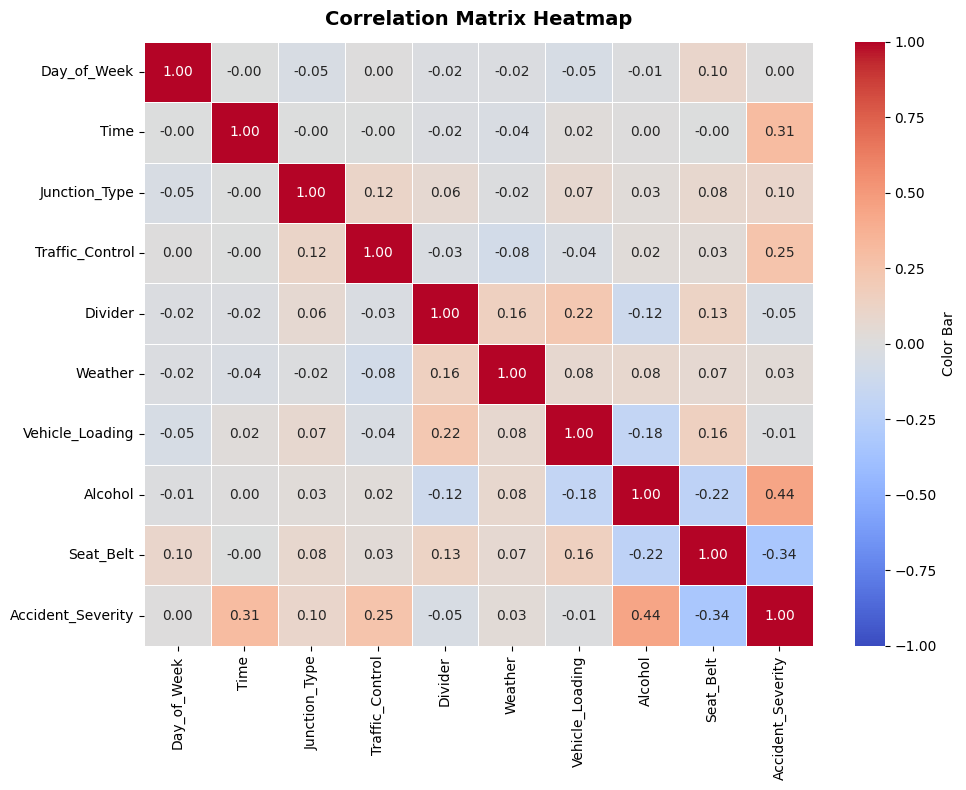

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm",  
    vmin=-1,
    vmax=1,  
    linewidths=0.5,  
    cbar_kws={"label": "Color Bar"})

plt.title("Correlation Matrix Heatmap", fontsize=14, pad=12, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [6]:
df.describe()

,Accident_Severity,Day_of_Week,Time,Junction_Type,Traffic_Control,Divider,Weather,Vehicle_Loading,Alcohol,Seat_Belt
count,480.00000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000
mean,0.48125,1.354167,3.783333,3.220833,3.431250,1.552083,1.229167,1.141667,1.679167,1.847917
std,0.50017,0.478759,1.684677,2.373563,2.602284,0.497799,0.653865,0.349072,0.467284,0.359476
min,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.00000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,0.00000,1.000000,4.000000,2.000000,3.000000,2.000000,1.000000,1.000000,2.000000,2.000000
75%,1.00000,2.000000,5.000000,5.000000,5.000000,2.000000,1.000000,1.000000,2.000000,2.000000
max,1.00000,2.000000,6.000000,7.000000,8.000000,2.000000,4.000000,2.000000,2.000000,2.000000


## Splitting the model into train and test sets

In [7]:
x = df.drop(['Accident_Severity'], axis=1)
y = df['Accident_Severity']
len(x), len(y)

(480, 480)

In [30]:
#Splitting the datset into 80% for training and 20% for testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
len(x_train),  len(x_test)

(336, 144)

## Decision Tree

Testing Accuracy: 83.33 %

                Classification Report - Decision Tree                 

+--------------+-------------+----------+------------+-----------+
|              |   precision |   recall |   f1-score |   support |
+==============+=============+==========+============+===========+
| Fatal        |      0.8116 |   0.8358 |     0.8235 |   67      |
+--------------+-------------+----------+------------+-----------+
| Non-Fatal    |      0.8533 |   0.8312 |     0.8421 |   77      |
+--------------+-------------+----------+------------+-----------+
| accuracy     |      0.8333 |   0.8333 |     0.8333 |    0.8333 |
+--------------+-------------+----------+------------+-----------+
| macro avg    |      0.8325 |   0.8335 |     0.8328 |  144      |
+--------------+-------------+----------+------------+-----------+
| weighted avg |      0.8339 |   0.8333 |     0.8335 |  144      |
+--------------+-------------+----------+------------+-----------+


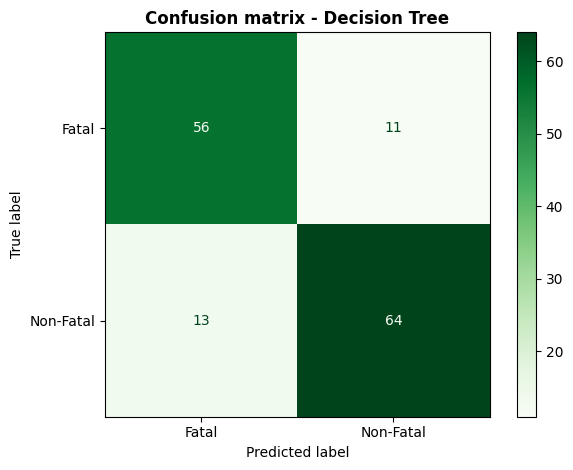

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

test_accuracy = accuracy_score(y_test, y_pred_dt)

print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")


print("\n" + "="*70)
print("Classification Report - Decision Tree".center(70))
print("="*70 + "\n")
print(pd.DataFrame(classification_report(y_test, y_pred_dt, target_names=["Fatal", "Non-Fatal"], output_dict=True)).transpose().round(4).to_markdown(tablefmt="grid"))

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fatal", "Non-Fatal"])

disp.plot(cmap= 'Greens')
plt.title("Confusion matrix - Decision Tree", fontweight= 'bold')
plt.tight_layout()
plt.show()

## Random Forest

Testing Accuracy  : 90.28 %

                Classification Report - Random Forest                 

+--------------+-------------+----------+------------+-----------+
|              |   precision |   recall |   f1-score |   support |
+==============+=============+==========+============+===========+
| Fatal        |      0.8841 |   0.9104 |     0.8971 |   67      |
+--------------+-------------+----------+------------+-----------+
| Non-Fatal    |      0.92   |   0.8961 |     0.9079 |   77      |
+--------------+-------------+----------+------------+-----------+
| accuracy     |      0.9028 |   0.9028 |     0.9028 |    0.9028 |
+--------------+-------------+----------+------------+-----------+
| macro avg    |      0.902  |   0.9033 |     0.9025 |  144      |
+--------------+-------------+----------+------------+-----------+
| weighted avg |      0.9033 |   0.9028 |     0.9029 |  144      |
+--------------+-------------+----------+------------+-----------+


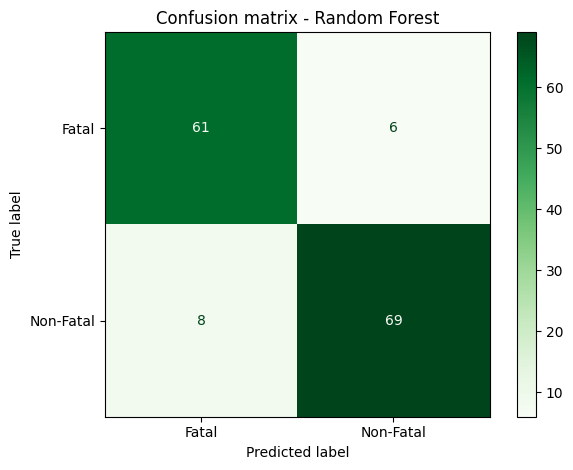

In [99]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

test_accuracy = accuracy_score(y_test, y_pred_rf)

print("Testing Accuracy  :", round(test_accuracy * 100, 2), "%")


print("\n" + "="*70)
print("Classification Report - Random Forest".center(70))
print("="*70 + "\n")
print(pd.DataFrame(classification_report(y_test, y_pred_rf, target_names=["Fatal", "Non-Fatal"], output_dict=True)).transpose().round(4).to_markdown(tablefmt="grid"))

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fatal", "Non-Fatal"])

disp.plot(cmap="Greens")
plt.title("Confusion matrix - Random Forest")
plt.tight_layout()
plt.show()

Testing Accuracy  : 88.89 %

                   Classification Report - XGBoost                    

+--------------+-------------+----------+------------+-----------+
|              |   precision |   recall |   f1-score |   support |
+==============+=============+==========+============+===========+
| Fatal        |      0.8592 |   0.9104 |     0.8841 |   67      |
+--------------+-------------+----------+------------+-----------+
| Non-Fatal    |      0.9178 |   0.8701 |     0.8933 |   77      |
+--------------+-------------+----------+------------+-----------+
| accuracy     |      0.8889 |   0.8889 |     0.8889 |    0.8889 |
+--------------+-------------+----------+------------+-----------+
| macro avg    |      0.8885 |   0.8903 |     0.8887 |  144      |
+--------------+-------------+----------+------------+-----------+
| weighted avg |      0.8905 |   0.8889 |     0.889  |  144      |
+--------------+-------------+----------+------------+-----------+


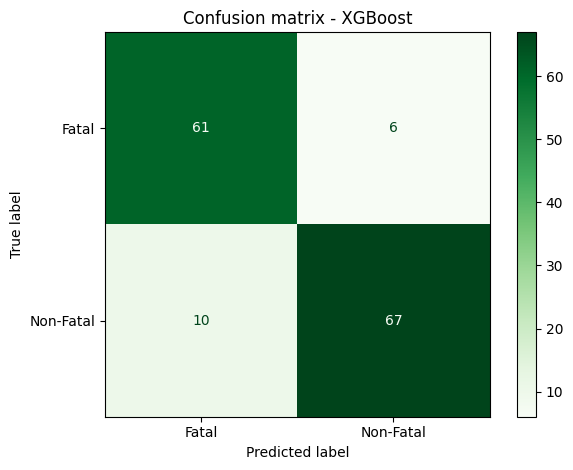

In [98]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100,
                   learning_rate=0.05,
                   max_depth=5,
                   random_state=42)
xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

test_accuracy = accuracy_score(y_test, y_pred_xgb)

print("Testing Accuracy  :", round(test_accuracy * 100, 2), "%")


print("\n" + "="*70)
print("Classification Report - XGBoost".center(70))
print("="*70 + "\n")
print(pd.DataFrame(classification_report(y_test, y_pred_xgb, target_names=["Fatal", "Non-Fatal"], output_dict=True)).transpose().round(4).to_markdown(tablefmt="grid"))

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fatal", "Non-Fatal"])

disp.plot(cmap='Greens')
plt.title("Confusion matrix - XGBoost")
plt.tight_layout()
plt.show()

## Hyperparameter tuning by grid search cross validation

### GS for Decition Tree

In [75]:
from sklearn.model_selection import GridSearchCV

param_dt = {"criterion"        : ["gini", "entropy", "log_loss"],
            "max_depth"        : [3, 5, 7, 10, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf" : [1, 2, 4],
            "max_features"     : ["sqrt", "log2", None]}

gs_dt = GridSearchCV(dt, param_dt, scoring="accuracy", cv=5, n_jobs=-1, verbose=1)

gs_dt.fit(x_train, y_train)

print("Best Parameters for DT :", gs_dt.best_params_)
print("Best CV Score   :", round(gs_dt.best_score_ * 100, 2), "%")

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
Best Parameters for DT : {'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Score   : 89.28 %


### GS for RF

In [85]:
param_rf = {"n_estimators"      : [100, 200, 300], "max_depth" : [3, 4, 5, 6], "min_samples_split" : [2, 5, 10], "min_samples_leaf"  : [1, 2, 5], "max_features"      : ["sqrt", "log2"]}


gs_rf = GridSearchCV(rf, param_rf, scoring = "accuracy", cv = 5, n_jobs= -1, verbose= 1)


gs_rf.fit(x_train, y_train)

print("Best Parameters for RF:", gs_rf.best_params_)
print("Best CV Score   :", round(gs_rf.best_score_ * 100, 2), "%")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters for RF: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score   : 88.99 %


### GS for XGBoost

In [ ]:
param_xgb = {"n_estimators"     : [100, 200, 300], "max_depth" : [3, 4, 5, 6], "learning_rate"    : [0.01, 0.05, 0.1], "subsample"        : [0.7, 0.8, 1.0], "colsample_bytree" : [0.7, 0.8, 1.0]}
gs_xgb = GridSearchCV(xgb,param_xgb,scoring="accuracy",cv=5,
    n_jobs=-1,
    verbose=1)
gs_xgb.fit(x_train, y_train)
print("Best Parameters for XGB:", gs_xgb.best_params_)
print("Best CV Score   :", round(gs_xgb.best_score_ * 100, 2), "%")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters for XGB: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score   : 90.47 %


## Rerunning the models by best hyperparameters

### Tuned DT Model

Testing Accuracy: 89.58 %

            Classification Report - Decision Tree (Tuned)             

+--------------+-------------+----------+------------+-----------+
|              |   precision |   recall |   f1-score |   support |
+==============+=============+==========+============+===========+
| Fatal        |      0.8714 |   0.9104 |     0.8905 |   67      |
+--------------+-------------+----------+------------+-----------+
| Non-Fatal    |      0.9189 |   0.8831 |     0.9007 |   77      |
+--------------+-------------+----------+------------+-----------+
| accuracy     |      0.8958 |   0.8958 |     0.8958 |    0.8958 |
+--------------+-------------+----------+------------+-----------+
| macro avg    |      0.8952 |   0.8968 |     0.8956 |  144      |
+--------------+-------------+----------+------------+-----------+
| weighted avg |      0.8968 |   0.8958 |     0.8959 |  144      |
+--------------+-------------+----------+------------+-----------+


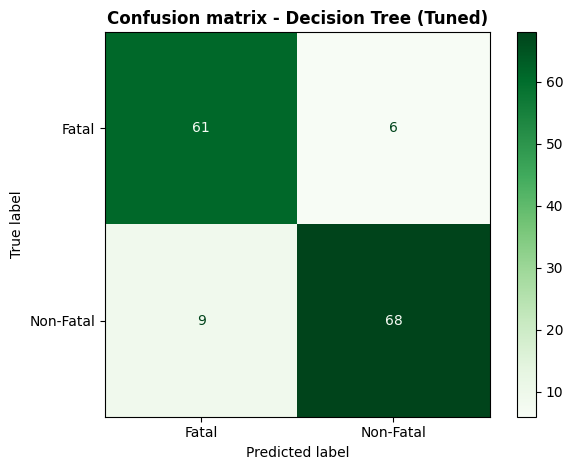

In [95]:
dt_tuned = gs_dt.best_estimator_
dt_tuned.fit(x_train, y_train)
y_pred_dt_tuned = dt_tuned.predict(x_test)
test_accuracy = accuracy_score(y_test, y_pred_dt_tuned)
print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")
print("\n" + "="*70)
print("Classification Report - Decision Tree (Tuned)".center(70))
print("="*70 + "\n")
print(pd.DataFrame(classification_report(y_test, y_pred_dt_tuned, target_names=["Fatal", "Non-Fatal"], output_dict=True)).transpose().round(4).to_markdown(tablefmt="grid"))
cm = confusion_matrix(y_test, y_pred_dt_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fatal", "Non-Fatal"])
disp.plot(cmap= 'Greens')
plt.title("Confusion matrix - Decision Tree (Tuned)", fontweight= 'bold')
plt.tight_layout()
plt.show()

### Tuned RF Model

Testing Accuracy: 90.28 %

            Classification Report - Random Forest (Tuned)             

+--------------+-------------+----------+------------+-----------+
|              |   precision |   recall |   f1-score |   support |
+==============+=============+==========+============+===========+
| Fatal        |      0.8732 |   0.9254 |     0.8986 |   67      |
+--------------+-------------+----------+------------+-----------+
| Non-Fatal    |      0.9315 |   0.8831 |     0.9067 |   77      |
+--------------+-------------+----------+------------+-----------+
| accuracy     |      0.9028 |   0.9028 |     0.9028 |    0.9028 |
+--------------+-------------+----------+------------+-----------+
| macro avg    |      0.9024 |   0.9042 |     0.9026 |  144      |
+--------------+-------------+----------+------------+-----------+
| weighted avg |      0.9044 |   0.9028 |     0.9029 |  144      |
+--------------+-------------+----------+------------+-----------+


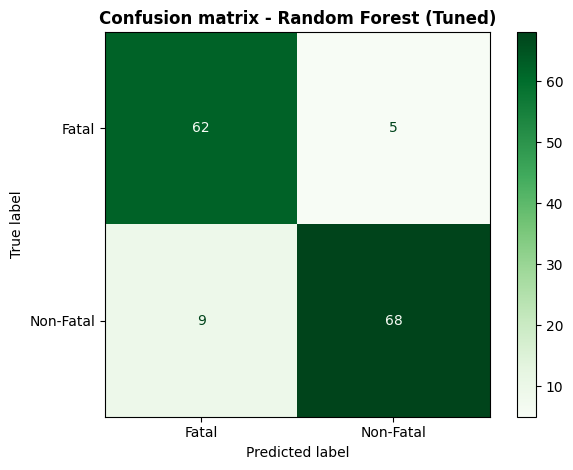

In [96]:
rf_tuned = gs_rf.best_estimator_
rf_tuned.fit(x_train, y_train)
y_pred_rf_tuned = rf_tuned.predict(x_test)
test_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")
print("\n" + "="*70)
print("Classification Report - Random Forest (Tuned)".center(70))
print("="*70 + "\n")
print(pd.DataFrame(classification_report(y_test, y_pred_rf_tuned, target_names=["Fatal", "Non-Fatal"], output_dict=True)).transpose().round(4).to_markdown(tablefmt="grid"))
cm = confusion_matrix(y_test, y_pred_rf_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fatal", "Non-Fatal"])
disp.plot(cmap= 'Greens')
plt.title("Confusion matrix - Random Forest (Tuned)", fontweight= 'bold')
plt.tight_layout()
plt.show()

### Tuned XGB Model

Testing Accuracy: 89.58 %

               Classification Report - XGBoost (Tuned)                

+--------------+-------------+----------+------------+-----------+
|              |   precision |   recall |   f1-score |   support |
+==============+=============+==========+============+===========+
| Fatal        |      0.8611 |   0.9254 |     0.8921 |   67      |
+--------------+-------------+----------+------------+-----------+
| Non-Fatal    |      0.9306 |   0.8701 |     0.8993 |   77      |
+--------------+-------------+----------+------------+-----------+
| accuracy     |      0.8958 |   0.8958 |     0.8958 |    0.8958 |
+--------------+-------------+----------+------------+-----------+
| macro avg    |      0.8958 |   0.8978 |     0.8957 |  144      |
+--------------+-------------+----------+------------+-----------+
| weighted avg |      0.8982 |   0.8958 |     0.896  |  144      |
+--------------+-------------+----------+------------+-----------+


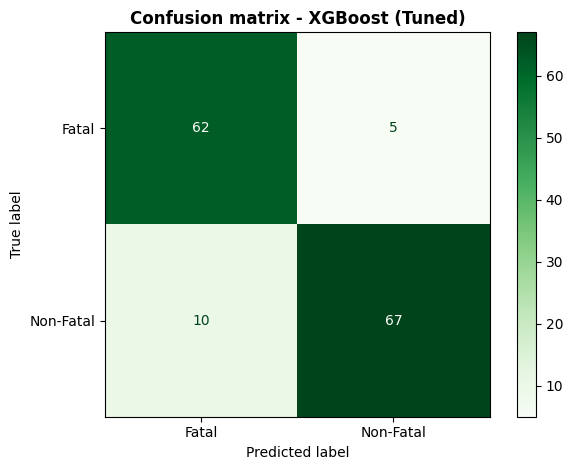

In [97]:
xgb_tuned = gs_xgb.best_estimator_
xgb_tuned.fit(x_train, y_train)
y_pred_xgb_tuned = xgb_tuned.predict(x_test)
test_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)
print("Testing Accuracy:", round(test_accuracy * 100, 2), "%")
print("\n" + "="*70)
print("Classification Report - XGBoost (Tuned)".center(70))
print("="*70 + "\n")
print(pd.DataFrame(classification_report(y_test, y_pred_xgb_tuned, target_names=["Fatal", "Non-Fatal"], output_dict=True)).transpose().round(4).to_markdown(tablefmt="grid"))
cm = confusion_matrix(y_test, y_pred_xgb_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fatal", "Non-Fatal"])
disp.plot(cmap= 'Greens')
plt.title("Confusion matrix - XGBoost (Tuned)", fontweight= 'bold')
plt.tight_layout()
plt.show()

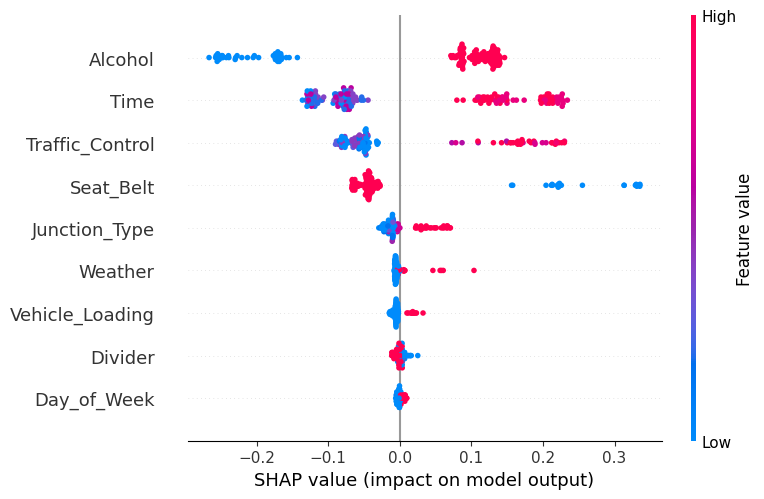

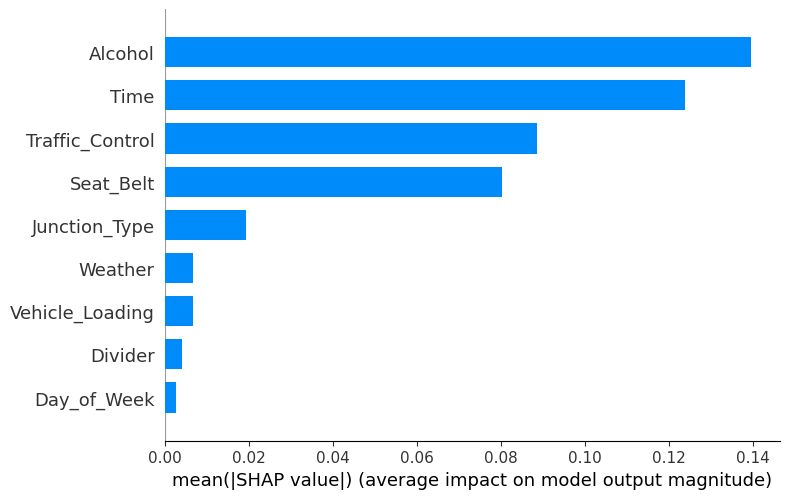


            Mean SHAP Values            
        Feature  Mean SHAP Value
        Alcohol         0.139504
           Time         0.123762
Traffic_Control         0.088668
      Seat_Belt         0.080333
  Junction_Type         0.019407
        Weather         0.006863
Vehicle_Loading         0.006808
        Divider         0.004089
    Day_of_Week         0.002689


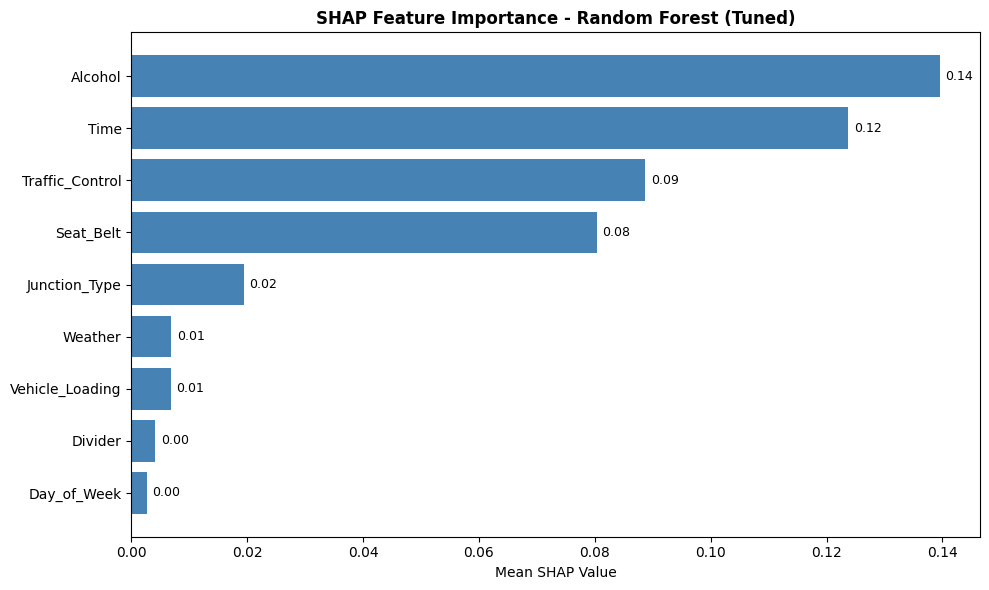

In [109]:
import shap

explainer   = shap.TreeExplainer(rf_tuned)
shap_values = explainer.shap_values(x_test)


plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],        # class 1 (Non-Fatal)
    x_test,
    feature_names = x_test.columns.tolist(),
    show          = True
)

# ==========================================================
# STEP 3: BAR PLOT (MEAN IMPORTANCE)
# ==========================================================
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],
    x_test,
    feature_names = x_test.columns.tolist(),
    plot_type     = "bar",
    show          = True
)

# ==========================================================
# STEP 4: SHAP VALUES AS DATAFRAME
# ==========================================================
shap_df = pd.DataFrame(
    shap_values[:, :, 1],
    columns = x_test.columns
)

mean_shap = shap_df.abs().mean().sort_values(
    ascending = False
).reset_index()

mean_shap.columns = ["Feature", "Mean SHAP Value"]

print("\n" + "="*40)
print("Mean SHAP Values".center(40))
print("="*40)
print(mean_shap.to_string(index=False))

# ==========================================================
# STEP 5: PLOT MEAN SHAP VALUES
# ==========================================================
plt.figure(figsize=(10, 6))
bars = plt.barh(
    mean_shap["Feature"],
    mean_shap["Mean SHAP Value"],
    color = "steelblue"
)

for bar, score in zip(bars, mean_shap["Mean SHAP Value"]):
    plt.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.2f}",
        va       = "center",
        fontsize = 9
    )

plt.gca().invert_yaxis()
plt.xlabel("Mean SHAP Value")
plt.title("SHAP Feature Importance - Random Forest (Tuned)",
          fontweight = "bold")
plt.tight_layout()
plt.show()